In [49]:
import joblib
import pandas as pd
import numpy as np

In [50]:
imputer = joblib.load("/Users/sadiqkhawaja/Desktop/PhD/CVD_RiskStrat_WebApp-merge-interface2/model_files/imputers/model1_sociodemographics_rf (1).pkl")
scaler = joblib.load("/Users/sadiqkhawaja/Desktop/PhD/CVD_RiskStrat_WebApp-merge-interface2/model_files/scalers/scaler.pkl")
model = joblib.load("/Users/sadiqkhawaja/Desktop/PhD/CVD_RiskStrat_WebApp-merge-interface2/model_files/ML_models/MRMR_COX_Sociodemographics.pkl")

/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.1 when using version 1.5.2. This might lea

In [51]:
sampleCols = list(imputer.feature_names_in_)
sample = pd.DataFrame(columns=sampleCols)

row = pd.Series(np.nan, index=sample.columns)

#NaNs instead
row = pd.Series(float('nan'), index=sample.columns)

#0s instead
#row = pd.Series(0, index=sample.columns)

In [52]:
backend_values = {
    "category_Sociodemographics_ts_Length.of.time.at.current.address...Instance.0": 5.0,

    "category_Sociodemographics_ts_Type.of.accommodation.lived.in...Instance.0_1": 1,

    'category_Sociodemographics_ts_Type.of.accommodation.lived.in...Instance.0_1':0,
    'category_Sociodemographics_ts_Type.of.accommodation.lived.in...Instance.0_4':0,
    'category_Sociodemographics_ts_Type.of.accommodation.lived.in...Instance.0_neg7':0,
    'category_Sociodemographics_ts_Type.of.accommodation.lived.in...Instance.0_3':0,
    'category_Sociodemographics_ts_Type.of.accommodation.lived.in...Instance.0_5':0,
    
     "Age.at.recruitment": 60.0
}

In [53]:
# Step 3: Fill row
for key, value in backend_values.items():
    if key in row.index:
        row[key] = value
    else:
        print(f"⚠️ Missing column in sample: {key}")

# Step 4: Convert to DataFrame
final_input = pd.DataFrame([row])

print(final_input.shape)  # should be (1, 96)

(1, 96)


In [54]:
final_inputImputed = imputer.transform(final_input)
final_inputImputed_Scaled = scaler.transform(final_inputImputed)
final_inputImputed_Scaled

[IterativeImputer] Completing matrix with shape (1, 96)
[IterativeImputer] Ending imputation round 1/3, elapsed time 1.25
[IterativeImputer] Ending imputation round 2/3, elapsed time 2.51
[IterativeImputer] Ending imputation round 3/3, elapsed time 3.74


array([[-2.61538462e+00, -4.71655439e-01, -4.53846154e+00,
        -4.46153846e+00, -4.46153846e+00, -4.46153846e+00,
        -4.46153846e+00, -8.43750000e-01, -4.89404147e-01,
        -4.06161626e-01, -5.57647684e-01, -6.38193202e-01,
        -5.17857143e-01, -8.94230769e-01, -7.00603141e-01,
        -3.94230769e-01, -1.57867628e-01, -4.01785714e-01,
        -4.48525037e-01, -1.87768656e-01, -5.51495042e-01,
        -5.52186701e-01, -4.39620112e-01, -5.45741758e-01,
        -4.21371273e-01, -5.00000000e-01, -4.05824604e-01,
        -7.09310615e-01, -7.42632817e-01, -5.25503962e-01,
        -4.14835790e-01, -4.31617092e-01, -3.67423720e-01,
        -5.66812902e-01, -7.66763508e-02, -4.59658946e-01,
        -4.21562830e-01, -6.69439588e-01, -4.85571055e-01,
        -5.75884086e-01, -1.44230769e-01, -7.60697297e-03,
        -8.07692308e-01, -3.17307692e-01, -3.87446852e-01,
        -3.55769231e-01, -4.23076923e-01, -4.13461538e-01,
        -1.64506629e-01, -3.36538462e-01, -2.50000000e-0

In [55]:
print(model.predict(final_inputImputed_Scaled))

[-4.85992642]


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but CoxPHSurvivalAnalysis was fitted with feature names
  warnings.warn(


In [56]:
ages = range(20, 91,10)

risks = []

for age in ages:

    test_row = row.copy()

    test_row["Age.at.recruitment"] = age
    print(age)

    test_df = pd.DataFrame([test_row])

    test_imp = imputer.transform(test_df)
    test_scaled = scaler.transform(test_imp)

    risk = model.predict(test_scaled)[0]

    risks.append(risk)

20
[IterativeImputer] Completing matrix with shape (1, 96)
[IterativeImputer] Ending imputation round 1/3, elapsed time 1.23
[IterativeImputer] Ending imputation round 2/3, elapsed time 2.49
[IterativeImputer] Ending imputation round 3/3, elapsed time 3.77
30
[IterativeImputer] Completing matrix with shape (1, 96)


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but CoxPHSurvivalAnalysis was fitted with feature names
  warnings.warn(


[IterativeImputer] Ending imputation round 1/3, elapsed time 1.21
[IterativeImputer] Ending imputation round 2/3, elapsed time 2.47
[IterativeImputer] Ending imputation round 3/3, elapsed time 3.73
40
[IterativeImputer] Completing matrix with shape (1, 96)


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but CoxPHSurvivalAnalysis was fitted with feature names
  warnings.warn(


[IterativeImputer] Ending imputation round 1/3, elapsed time 1.25
[IterativeImputer] Ending imputation round 2/3, elapsed time 2.52
[IterativeImputer] Ending imputation round 3/3, elapsed time 3.79
50
[IterativeImputer] Completing matrix with shape (1, 96)


...

/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but CoxPHSurvivalAnalysis was fitted with feature names
  warnings.warn(


[IterativeImputer] Ending imputation round 1/3, elapsed time 1.31
[IterativeImputer] Ending imputation round 2/3, elapsed time 2.58
[IterativeImputer] Ending imputation round 3/3, elapsed time 3.82
90
[IterativeImputer] Completing matrix with shape (1, 96)


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but CoxPHSurvivalAnalysis was fitted with feature names
  warnings.warn(


[IterativeImputer] Ending imputation round 1/3, elapsed time 1.28
[IterativeImputer] Ending imputation round 2/3, elapsed time 2.56
[IterativeImputer] Ending imputation round 3/3, elapsed time 3.87


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but CoxPHSurvivalAnalysis was fitted with feature names
  warnings.warn(


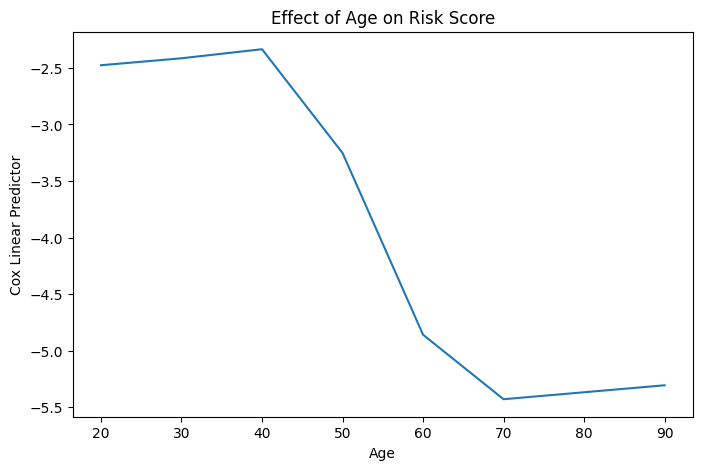

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(ages, risks)
plt.xlabel("Age")
plt.ylabel("Cox Linear Predictor")
plt.title("Effect of Age on Risk Score")
plt.show()